# Stage 4 — Conditional opportunity and entitlement economics

**All economic numbers are D assumptions, not forecasts, real ROI or experimental effects.** H1: existing individual iOS accounts, Japanese L1 English learners in Japan around course B1.1. Actual speaking level and account entitlement require separate screening. H=90 days is a design choice. The three original tiers are reported separately; weights and deployment size are unknown.

Read [business review](stage4_business_review.md), [assumptions](assumptions.md) and [policy evidence](policy_evidence.md) before using these results. P0 account rights are unverified. No published learning score, company growth or VOC proportion calibrates economic inputs.

## Rebuild and inspect the input contract

Run from repository root using the existing Stage 3 dependencies. No network, secrets or new packages. Four derivative CSVs and two plots are generated; scenario_inputs.json is the authoritative D input.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, HTML, Image
ROOT = Path.cwd().resolve()
if not (ROOT / 'quant/scenario_inputs.json').is_file():
    raise RuntimeError('Execute with cwd at repository root')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from quant.opportunity_model import run, table_html
result = run(ROOT)
print('D conditional model generated:', {k:len(v) for k,v in result['tables'].items()})
print('Actual economics: NOT IDENTIFIED. No cross-tier ranking or total forecast.')

D conditional model generated: {'results': 27, 'paths': 81, 'thresholds': 18, 'sensitivity': 360}
Actual economics: NOT IDENTIFIED. No cross-tier ranking or total forecast.


## Accounting model

For each originally assigned tier s and policy p: v = delta_m - delta_c - F/N_deployment. Zero users stay in the denominator. m is H-period net contribution before AI cost, with whole billing paths and necessary non-AI fees/refunds; c includes offer attempts plus non-offer paid workload. P0's *relative* effect is zero, while its absolute serving cost may be nonzero.

Marginal probabilities q0 and qp each sum to one. D gain/loss shifts are a scenario construction, not observable joint counterfactual transitions. Common path contributions/workloads across arms are explicit D assumptions. Upgrades and renewals are not added twice; no extra adoption multiplier is applied to full-assignment billing outcomes.

An illustrative common service-minute rate combines an unknown provider stack; it is not learner speaking time or actual Duolingo cost. Failed attempts consume workload and no effective minutes. Retries are already attempts. The normalized 1000 accounts do not determine deployment size, fixed-cost allocation or original-tier weights.

In [2]:
primary = [r for r in result['tables']['results'] if (r['policy_id'], r['original_tier']) in [('P0','Super'), ('P1','Super'), ('P2','Free')]]
display(HTML(table_html(primary, ['policy_id','scenario_id','original_tier','delta_non_ai_contribution_usd','delta_ai_and_service_cost_usd','fixed_cost_per_target_account_demo_usd','net_contribution_usd_per_account_demo'])))

policy_id,scenario_id,original_tier,delta_non_ai_contribution_usd,delta_ai_and_service_cost_usd,fixed_cost_per_target_account_demo_usd,net_contribution_usd_per_account_demo
P0,low,Super,0,0,0,0
P0,base,Super,0,0,0,0
P0,high,Super,0,0,0,0
P1,low,Super,0.132,0.01955,0.05,0.06245
P1,base,Super,0.24,0.20926,0.05,-0.01926
P1,high,Super,0.504,1.01434,0.05,-0.560336
P2,low,Free,0.036,0.010895,0.05,-0.024895
P2,base,Free,0.132,0.07226,0.05,0.00974
P2,high,Free,0.276,0.343232,0.05,-0.117232


## D scenarios: response intensity is not economic optimism

Shared low/reference/high intensity assumptions increase use as well as costs. Any positive or negative number describes only authored inputs. Different tiers are not ranked.

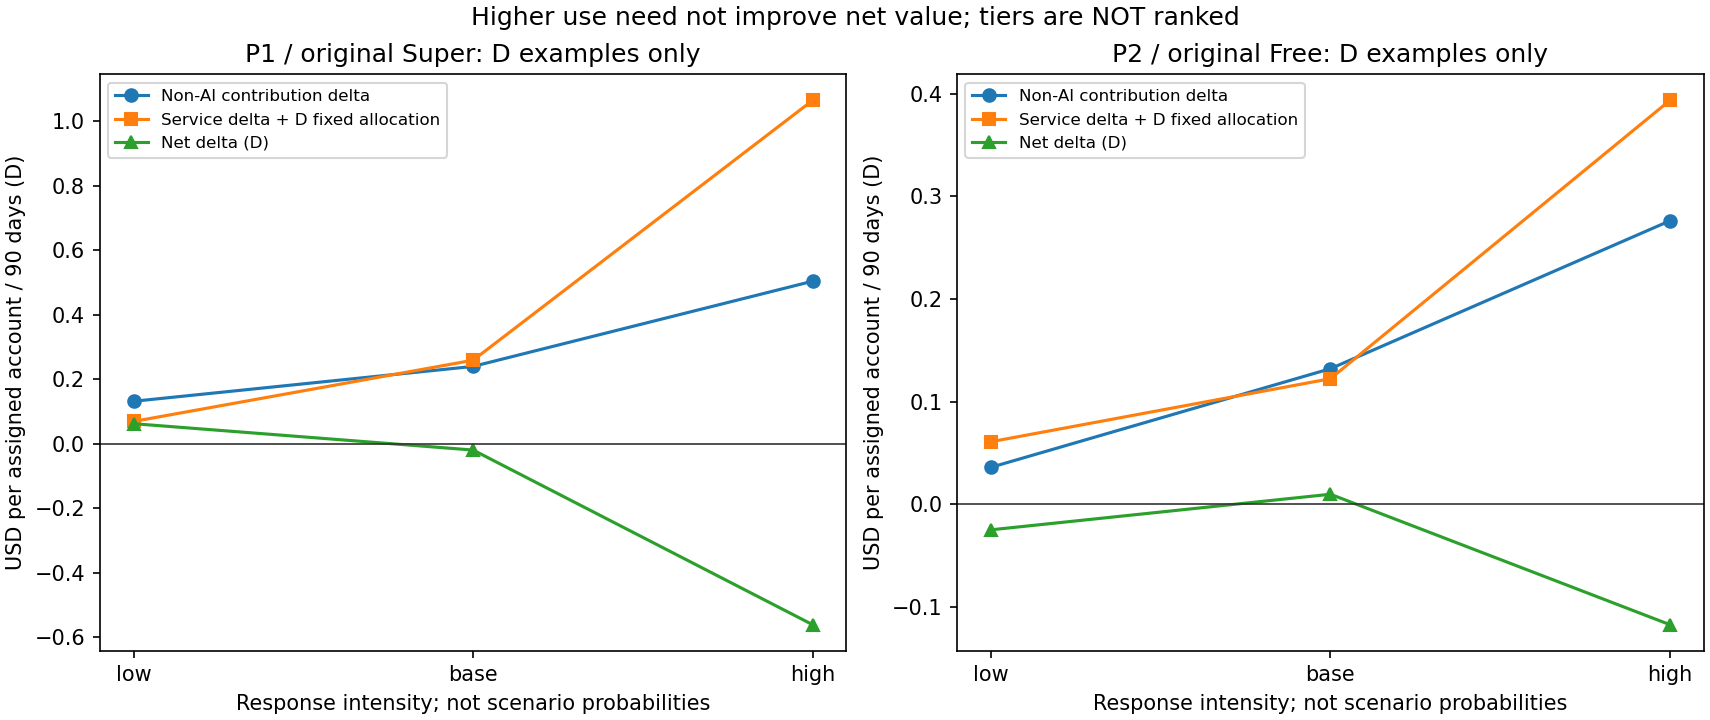

In [3]:
display(Image(filename=result['figures'][0]))

## Exact conditional thresholds

If donor-to-gain net marginal contribution G = delta_path_m - k*delta_path_u is positive, g_min = (loss_rate*L + k*offer_workload + other_delta_cost + f) / G. L includes serving-cost savings on a lost expensive paid path. Probabilities must remain feasible. This holds offer workload fixed but recomputes paid workload as the billing gain/loss rate changes. No effect is estimated. G<=0 changes or removes the inequality direction.

For common price k and delta_u>0, k_max=(delta_m-other_delta_cost-f)/delta_u. If delta_u<0 it is a lower-bound condition; if zero there is no price threshold. All fixed-cost values below are D allocations, not F divided by 1000.

In [4]:
thresholds = [r for r in result['tables']['thresholds'] if (r['policy_id'],r['original_tier']) in [('P1','Super'),('P2','Free')]]
display(HTML(table_html(thresholds, ['policy_id','scenario_id','original_tier','gain_rate_break_even','gain_constraint','economically_feasible_gain_exists_in_D_generator','unit_cost_break_even_usd_per_service_minute','unit_cost_constraint'])))

policy_id,scenario_id,original_tier,gain_rate_break_even,gain_constraint,economically_feasible_gain_exists_in_D_generator,unit_cost_break_even_usd_per_service_minute,unit_cost_constraint
P1,low,Super,0.0130611,lower_bound,True,0.167775,upper_bound
P1,base,Super,0.04214,lower_bound,True,0.0363185,upper_bound
P1,high,Super,0.14226,lower_bound,True,0.0179033,upper_bound
P2,low,Free,0.00710262,lower_bound,True,-0.0513997,upper_bound
P2,base,Free,0.0141774,lower_bound,True,0.0453916,upper_bound
P2,high,Free,0.0399014,lower_bound,True,0.0263379,upper_bound


## Joint cost / diversion sensitivity

The black line is the algebraic zero-net boundary in an uncalibrated D domain. The displayed loss is foregone Max purchase/upgrade in Free/Super, not original-Max downgrade. 360 discrete scans are exported in stage4_sensitivity.csv. The smooth chart grid is presentation-only and reconstructible from this code, not extra observations, probability mass or confidence intervals.

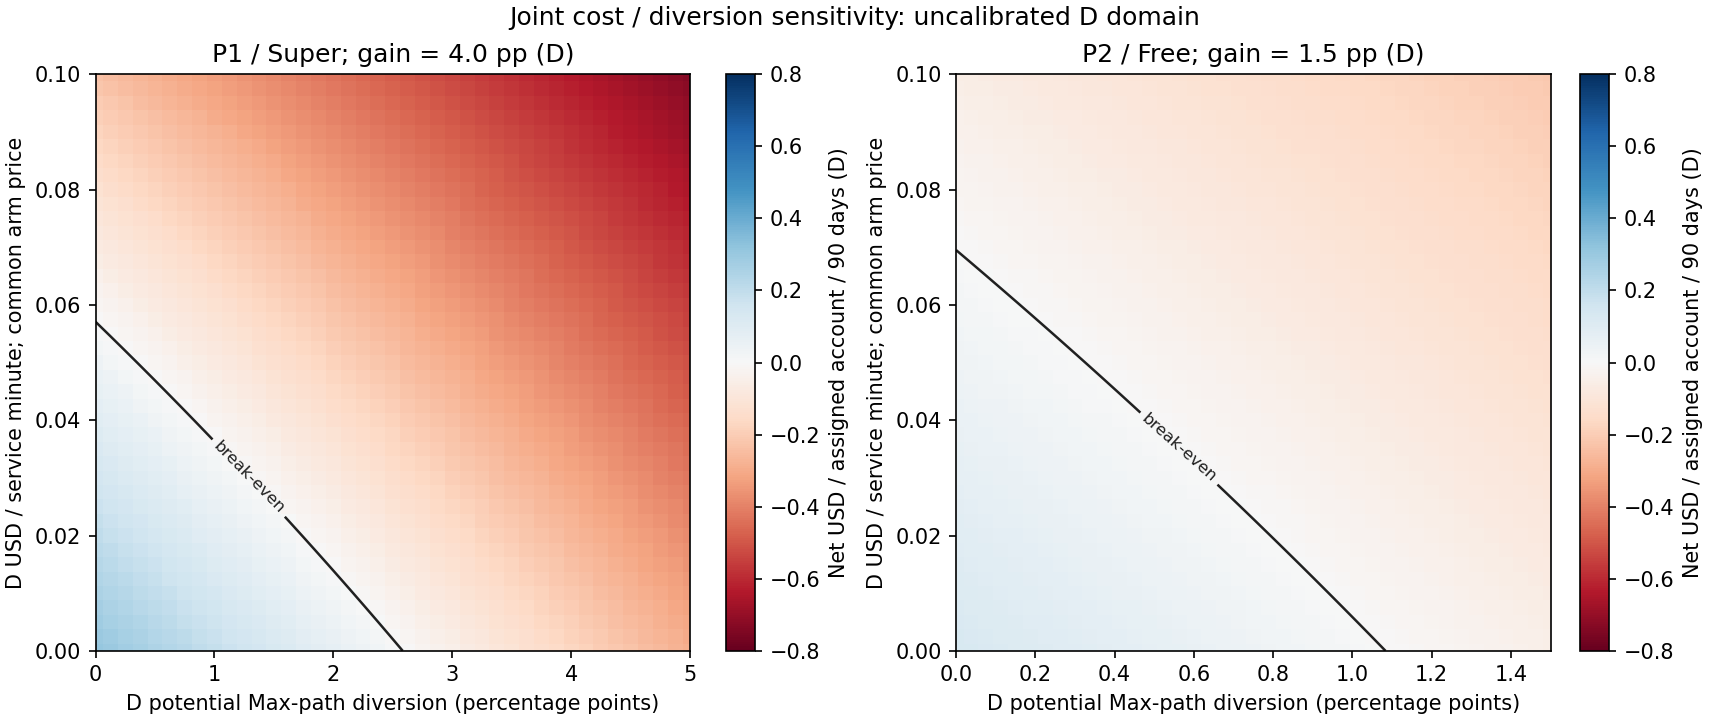

In [5]:
display(Image(filename=result['figures'][1]))

## Spillovers and omitted total ranking

Original Max downgrade is modeled separately as a D information/entitlement spillover. A trial restricted to original Super accounts cannot identify this original Max effect. No real spillover is currently measured; separate exposure evidence is required. Other unaffected layers have zero by a D assumption, not an observed null result.

In [6]:
spillovers = [r for r in result['tables']['results'] if r['policy_id']!='P0' and r['original_tier']!='none' and r['scope']=='hypothetical_spillover_D']
display(HTML(table_html(spillovers,['policy_id','scenario_id','original_tier','gain_rate_demo','loss_rate_demo','delta_non_ai_contribution_usd','delta_ai_and_service_cost_usd','net_contribution_usd_per_account_demo'])))

policy_id,scenario_id,original_tier,gain_rate_demo,loss_rate_demo,delta_non_ai_contribution_usd,delta_ai_and_service_cost_usd,net_contribution_usd_per_account_demo
P1,low,Max,0,0.003,-0.03,-0.00192,-0.02808
P1,base,Max,0,0.006,-0.06,-0.00384,-0.05616
P1,high,Max,0,0.01,-0.1,-0.0064,-0.0936
P2,low,Super,0,0.001,-0.012,-0.0008,-0.0112
P2,low,Max,0,0.001,-0.01,-0.00064,-0.00936
P2,base,Super,0,0.002,-0.024,-0.0016,-0.0224
P2,base,Max,0,0.002,-0.02,-0.00128,-0.01872
P2,high,Super,0,0.004,-0.048,-0.0032,-0.0448
P2,high,Max,0,0.004,-0.04,-0.00256,-0.03744


## Decision handoff

Market evidence supports H1 as the priority learning task; public business data makes substitution/cost material, not identified. The model defines break-even conditions and required data. **No unconditional P1/P2 winner.** Stage 5 should first qualify a genuine incremental offer and measure natural effective practice, all-assigned billing contribution and serving workload, while tracking independent unpracticed learning tasks and course displacement. A per-Super test leaves Max spillover and total policy value unresolved. No sample-size claim is made without a matching baseline/variance.

Fresh-process execution: `python -B scripts/run_stage4.py --execute-direct`. Independent numerical verification: `python -B scripts/verify_stage4.py`. Direct sequential code execution with captured real outputs is not standard Jupyter kernel validation.